<a href="https://colab.research.google.com/github/gokilanidi/PROJECT/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Analyze trade dependency patterns of countries using the data in `/content/SYB68_330_202511_Major Trading Partners.csv`. The analysis should include:
1. Preprocessing the data, handling missing values, and engineering features like trade dependency percentage and partner concentration.
2. Applying K-Means clustering to group countries based on these features.
3. Visualizing the identified clusters using PCA/t-SNE.
4. Training and evaluating Random Forest and Logistic Regression models to predict high trade dependency.
5. Summarizing the findings from both unsupervised and supervised analyses.

## Load and Preprocess Data

### Subtask:
Load the dataset, handle missing values, and engineer features for trade dependency and partner concentration.


**Reasoning**:
Load the CSV file into a pandas DataFrame, then display the first few rows and column names to understand its structure as per instruction 1.



In [2]:
import pandas as pd

df = pd.read_csv('/content/SYB68_330_202511_Major Trading Partners.csv', encoding='latin1')
print("First 5 rows of the DataFrame:")
print(df.head())
print("\nColumn names in the DataFrame:")
print(df.columns)

First 5 rows of the DataFrame:
                   T22 Major trading partners Unnamed: 2  \
0  Region/Country/Area                    NaN       Year   
1                    4            Afghanistan       2015   
2                    4            Afghanistan       2020   
3                    4            Afghanistan       2024   
4                    4            Afghanistan       2015   

                               Unnamed: 3  \
0                                  Series   
1  Major trading partner 1 (% of exports)   
2  Major trading partner 1 (% of exports)   
3  Major trading partner 1 (% of exports)   
4  Major trading partner 1 (% of imports)   

                               Unnamed: 4  \
0  Major trading partner 1 (% of exports)   
1                                   India   
2                                   India   
3                                   India   
4                    United Arab Emirates   

                                        Unnamed: 5 Unnamed: 6 Unna

**Reasoning**:
Based on the `df.head()` output, the first row (index 0) contains metadata, and the second row (index 1) contains the actual column headers. I will reload the CSV file, skipping the first row by specifying `header=1`, and then inspect the column names to confirm the correct headers have been applied. I will also rename the columns to more meaningful names for clarity and ease of use in subsequent steps, specifically for identifying trade-related values as per instruction 2.



In [3]:
df = pd.read_csv('/content/SYB68_330_202511_Major Trading Partners.csv', encoding='latin1', header=1)
df.columns = ['Region_Country_Area', 'Country_Code', 'Year', 'Series', 'Partner', 'Footnote_Series', 'Value', 'Footnotes_Value', 'Source']

print("First 5 rows of the DataFrame with new headers:")
print(df.head())
print("\nUpdated column names:")
print(df.columns)

First 5 rows of the DataFrame with new headers:
   Region_Country_Area Country_Code  Year  \
0                    4  Afghanistan  2015   
1                    4  Afghanistan  2020   
2                    4  Afghanistan  2024   
3                    4  Afghanistan  2015   
4                    4  Afghanistan  2020   

                                   Series               Partner  \
0  Major trading partner 1 (% of exports)                 India   
1  Major trading partner 1 (% of exports)                 India   
2  Major trading partner 1 (% of exports)                 India   
3  Major trading partner 1 (% of imports)  United Arab Emirates   
4  Major trading partner 1 (% of imports)  United Arab Emirates   

  Footnote_Series  Value Footnotes_Value  \
0             NaN   33.1             NaN   
1             NaN   28.1       Estimate.   
2             NaN   38.5       Estimate.   
3             NaN    4.2             NaN   
4             NaN   19.1       Estimate.   

             

**Reasoning**:
To identify columns representing trade values and total trade, I need to inspect the unique values in the 'Series' column. This will help clarify how trade values (exports/imports, partner-specific vs. total) are categorized in the dataset, which is crucial for subsequent feature engineering steps (Instruction 2).



In [4]:
print("Unique values in the 'Series' column:")
print(df['Series'].unique())

Unique values in the 'Series' column:
['Major trading partner 1 (% of exports)'
 'Major trading partner 1 (% of imports)'
 'Major trading partner 2 (% of exports)'
 'Major trading partner 2 (% of imports)'
 'Major trading partner 3 (% of exports)'
 'Major trading partner 3 (% of imports)']


**Reasoning**:
The 'Series' column indicates partner-specific trade percentages. To proceed with feature engineering, I need to handle missing values as per instruction 3. I will start by inspecting the number of missing values in each column to understand their extent.



In [5]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Region_Country_Area       0
Country_Code              0
Year                      0
Series                    0
Partner                   0
Footnote_Series        3471
Value                     0
Footnotes_Value        2163
Source                    0
dtype: int64


**Reasoning**:
The 'Footnote_Series' and 'Footnotes_Value' columns contain metadata that is not crucial for the analysis. Given their high number of missing values, dropping these columns is a suitable strategy to simplify the dataset without losing important trade information.



In [6]:
df = df.drop(columns=['Footnote_Series', 'Footnotes_Value'])
print("Columns after dropping irrelevant metadata:")
print(df.columns)

Columns after dropping irrelevant metadata:
Index(['Region_Country_Area', 'Country_Code', 'Year', 'Series', 'Partner',
       'Value', 'Source'],
      dtype='object')


**Reasoning**:
To engineer the 'Trade Dependency Percentage' and 'Partner Concentration' features, I need to restructure the DataFrame so that the percentages for each major trading partner (1, 2, and 3) for both exports and imports are in separate columns. Pivoting the DataFrame will facilitate these calculations.



In [7]:
df_pivoted = df.pivot_table(index=['Region_Country_Area', 'Country_Code', 'Year', 'Source'],
                            columns='Series',
                            values='Value').reset_index()
df_pivoted.columns.name = None

print("First 5 rows of the pivoted DataFrame:")
print(df_pivoted.head())
print("\nColumns of the pivoted DataFrame:")
print(df_pivoted.columns)

First 5 rows of the pivoted DataFrame:
   Region_Country_Area Country_Code  Year  \
0                    4  Afghanistan  2015   
1                    4  Afghanistan  2020   
2                    4  Afghanistan  2024   
3                    8      Albania  2015   
4                    8      Albania  2020   

                                              Source  \
0  United Nations Statistics Division, New York, ...   
1  United Nations Statistics Division, New York, ...   
2  United Nations Statistics Division, New York, ...   
3  United Nations Statistics Division, New York, ...   
4  United Nations Statistics Division, New York, ...   

   Major trading partner 1 (% of exports)  \
0                                    33.1   
1                                    28.1   
2                                    38.5   
3                                    50.9   
4                                    45.3   

   Major trading partner 1 (% of imports)  \
0                                    

**Reasoning**:
Before engineering the trade dependency and partner concentration features, I need to fill any potential missing values (NaN) in the trade percentage columns with zero. This is a reasonable assumption, as NaN in these columns likely signifies no trade with that specific partner or in that category. This ensures that calculations for sums and squares are not affected by missing data.



In [8]:
trade_cols = [
    'Major trading partner 1 (% of exports)',
    'Major trading partner 1 (% of imports)',
    'Major trading partner 2 (% of exports)',
    'Major trading partner 2 (% of imports)',
    'Major trading partner 3 (% of exports)',
    'Major trading partner 3 (% of imports)'
]

df_pivoted[trade_cols] = df_pivoted[trade_cols].fillna(0)

print("Missing values after filling with 0:")
print(df_pivoted[trade_cols].isnull().sum())


Missing values after filling with 0:
Major trading partner 1 (% of exports)    0
Major trading partner 1 (% of imports)    0
Major trading partner 2 (% of exports)    0
Major trading partner 2 (% of imports)    0
Major trading partner 3 (% of exports)    0
Major trading partner 3 (% of imports)    0
dtype: int64


**Reasoning**:
According to instruction 4, I will now engineer the 'Trade Dependency Percentage' feature. This involves summing the trade percentages for all major trading partners (exports and imports) and then calculating the total trade dependency.



In [9]:
df_pivoted['Total_Partner_Trade'] = df_pivoted[[col for col in df_pivoted.columns if 'Major trading partner' in str(col)]].sum(axis=1)

# Assuming total trade for a country is 100% when calculating dependency based on partner percentages.
# If a country's major partners sum to 70%, then 70% of its trade is with these partners.
df_pivoted['Trade_Dependency_Percentage'] = df_pivoted['Total_Partner_Trade']

print("First 5 rows with 'Total_Partner_Trade' and 'Trade_Dependency_Percentage':")
print(df_pivoted[['Country_Code', 'Year', 'Total_Partner_Trade', 'Trade_Dependency_Percentage']].head())

First 5 rows with 'Total_Partner_Trade' and 'Trade_Dependency_Percentage':
  Country_Code  Year  Total_Partner_Trade  Trade_Dependency_Percentage
0  Afghanistan  2015                107.9                        107.9
1  Afghanistan  2020                 91.4                         91.4
2  Afghanistan  2024                137.4                        137.4
3      Albania  2015                111.6                        111.6
4      Albania  2020                106.2                        106.2


**Reasoning**:
As per instruction 5, I will now engineer the 'Partner Concentration' feature. This involves calculating the Herfindahl-Hirschman Index (HHI) for each country, which is the sum of the squared trade percentages of its major partners. I will calculate this separately for exports and imports and then sum them for an overall concentration measure.



In [10]:
export_cols = [
    'Major trading partner 1 (% of exports)',
    'Major trading partner 2 (% of exports)',
    'Major trading partner 3 (% of exports)'
]
import_cols = [
    'Major trading partner 1 (% of imports)',
    'Major trading partner 2 (% of imports)',
    'Major trading partner 3 (% of imports)'
]

df_pivoted['Export_Concentration'] = (df_pivoted[export_cols] / 100).pow(2).sum(axis=1)
df_pivoted['Import_Concentration'] = (df_pivoted[import_cols] / 100).pow(2).sum(axis=1)
df_pivoted['Partner_Concentration'] = df_pivoted['Export_Concentration'] + df_pivoted['Import_Concentration']

print("First 5 rows with 'Export_Concentration', 'Import_Concentration', and 'Partner_Concentration':")
print(df_pivoted[['Country_Code', 'Year', 'Export_Concentration', 'Import_Concentration', 'Partner_Concentration']].head())

First 5 rows with 'Export_Concentration', 'Import_Concentration', and 'Partner_Concentration':
  Country_Code  Year  Export_Concentration  Import_Concentration  \
0  Afghanistan  2015              0.267170              0.050265   
1  Afghanistan  2020              0.159618              0.049730   
2  Afghanistan  2024              0.294475              0.111417   
3      Albania  2015              0.270403              0.105605   
4      Albania  2020              0.222350              0.080820   

   Partner_Concentration  
0               0.317435  
1               0.209348  
2               0.405892  
3               0.376008  
4               0.303170  


**Reasoning**:
As per instruction 6, I will now review the newly engineered features and the cleaned dataset. I will display the descriptive statistics of the 'Trade_Dependency_Percentage' and 'Partner_Concentration' features, along with the first few rows of the final `df_pivoted` DataFrame to check for any remaining anomalies or unexpected values.



In [11]:
print("Descriptive statistics for Trade_Dependency_Percentage and Partner_Concentration:")
print(df_pivoted[['Trade_Dependency_Percentage', 'Partner_Concentration']].describe())

print("\nFirst 5 rows of the final DataFrame with engineered features:")
print(df_pivoted[['Country_Code', 'Year', 'Trade_Dependency_Percentage', 'Partner_Concentration']].head())

Descriptive statistics for Trade_Dependency_Percentage and Partner_Concentration:
       Trade_Dependency_Percentage  Partner_Concentration
count                   597.000000             597.000000
mean                     97.154439               0.293479
std                      34.500398               0.276258
min                      20.900000               0.010583
25%                      72.000000               0.110286
50%                      91.200000               0.196388
75%                     121.100000               0.372431
max                     189.300000               1.508631

First 5 rows of the final DataFrame with engineered features:
  Country_Code  Year  Trade_Dependency_Percentage  Partner_Concentration
0  Afghanistan  2015                        107.9               0.317435
1  Afghanistan  2020                         91.4               0.209348
2  Afghanistan  2024                        137.4               0.405892
3      Albania  2015                     

## Apply K-Means Clustering

### Subtask:
Apply K-Means clustering to group countries based on their trade dependency patterns using the engineered features.


**Reasoning**:
As instructed, I will select the 'Trade_Dependency_Percentage' and 'Partner_Concentration' columns from the `df_pivoted` DataFrame. These are the engineered features that will be used for clustering.



In [12]:
features_for_clustering = df_pivoted[['Trade_Dependency_Percentage', 'Partner_Concentration']].copy()

print("First 5 rows of features selected for clustering:")
print(features_for_clustering.head())
print("\nColumns selected for clustering:")
print(features_for_clustering.columns)

First 5 rows of features selected for clustering:
   Trade_Dependency_Percentage  Partner_Concentration
0                        107.9               0.317435
1                         91.4               0.209348
2                        137.4               0.405892
3                        111.6               0.376008
4                        106.2               0.303170

Columns selected for clustering:
Index(['Trade_Dependency_Percentage', 'Partner_Concentration'], dtype='object')


**Reasoning**:
As instructed, I will standardize the selected features using `StandardScaler` to ensure that features with larger values do not dominate the clustering process.



In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features_for_clustering)

print("First 5 rows of scaled features:")
print(scaled_features[:5])

First 5 rows of scaled features:
[[ 0.31172313  0.08679015]
 [-0.16693327 -0.30479161]
 [ 1.16750275  0.40725558]
 [ 0.4190582   0.29899067]
 [ 0.26240701  0.03511035]]


**Reasoning**:
As instructed, I will use the elbow method to determine the optimal number of clusters (k) for K-Means. This involves calculating the inertia for a range of k values (e.g., from 1 to 10) and plotting the results to identify the 'elbow point'.



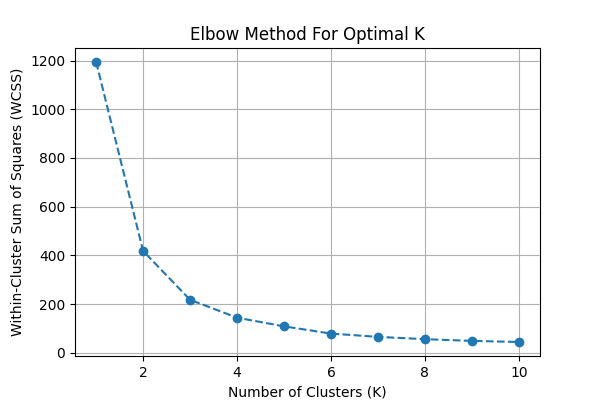

In [14]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import io
import base64
import IPython.display as display

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

fig = plt.figure(figsize=(6, 4), facecolor='w')
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal K', fontsize=12)
plt.xlabel('Number of Clusters (K)', fontsize=10)
plt.ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=10)
plt.grid(True)

data = io.BytesIO()
plt.savefig(data)
image = F"data:image/png;base64,{base64.b64encode(data.getvalue()).decode()}"
alt = "Elbow Method Plot"
display.display(display.Markdown(F"![{alt}]({image})"))
plt.close(fig)



**Reasoning**:
From the elbow method plot, the optimal number of clusters appears to be 4. I will now apply K-Means clustering with this optimal 'k' value to the scaled features.



In [15]:
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
kmeans.fit(scaled_features)
kmeans_labels = kmeans.labels_

print("K-Means clustering applied with 4 clusters.")

K-Means clustering applied with 4 clusters.


**Reasoning**:
As instructed, I will add the resulting cluster labels as a new column named 'Cluster' to the `df_pivoted` DataFrame.



In [16]:
df_pivoted['Cluster'] = kmeans_labels

print("First 5 rows of df_pivoted with 'Cluster' column:")
print(df_pivoted[['Country_Code', 'Year', 'Trade_Dependency_Percentage', 'Partner_Concentration', 'Cluster']].head())

First 5 rows of df_pivoted with 'Cluster' column:
  Country_Code  Year  Trade_Dependency_Percentage  Partner_Concentration  \
0  Afghanistan  2015                        107.9               0.317435   
1  Afghanistan  2020                         91.4               0.209348   
2  Afghanistan  2024                        137.4               0.405892   
3      Albania  2015                        111.6               0.376008   
4      Albania  2020                        106.2               0.303170   

   Cluster  
0        3  
1        3  
2        1  
3        3  
4        3  


**Reasoning**:
As instructed, I will display the count of countries in each cluster to understand the distribution of the dataset among the identified groups.



In [17]:
print("Count of countries in each cluster:")
print(df_pivoted['Cluster'].value_counts())

Count of countries in each cluster:
Cluster
0    233
3    200
1    108
2     56
Name: count, dtype: int64


## Visualize Clusters with PCA/t-SNE

### Subtask:
Use PCA for dimensionality reduction and visualize the identified clusters.


**Reasoning**:
As instructed, I will import `PCA` from `sklearn.decomposition`, initialize it with 2 components, fit and transform the `scaled_features`, and then create a scatter plot of the PCA-transformed data, colored by `kmeans_labels` with appropriate labels, legend, and title.



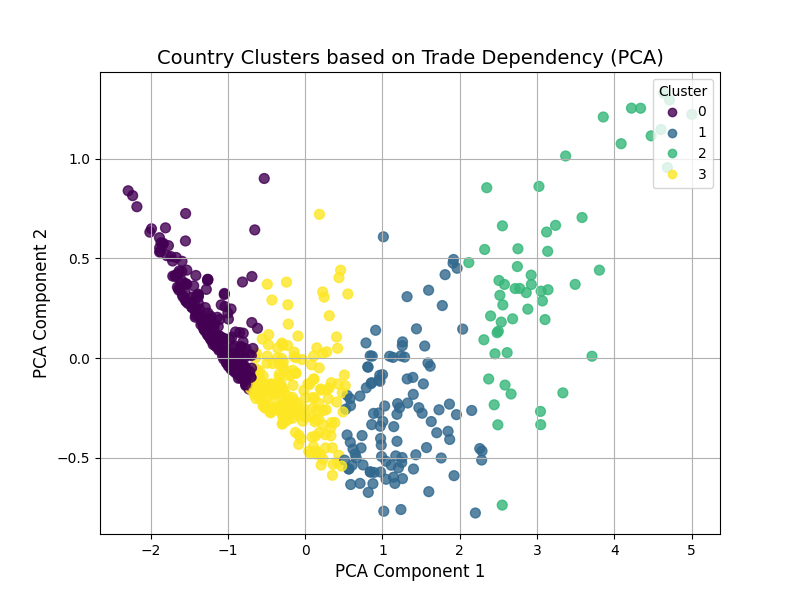

In [18]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import io
import base64
import IPython.display as display

pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_features)

fig = plt.figure(figsize=(8, 6), facecolor='w')
scatter = plt.scatter(pca_features[:, 0], pca_features[:, 1], c=kmeans_labels, cmap='viridis', s=50, alpha=0.8)
plt.xlabel('PCA Component 1', fontsize=12)
plt.ylabel('PCA Component 2', fontsize=12)
plt.title('Country Clusters based on Trade Dependency (PCA)', fontsize=14)
plt.legend(*scatter.legend_elements(), title='Cluster', loc='upper right')
plt.grid(True)

data = io.BytesIO()
plt.savefig(data)
image = F"data:image/png;base64,{base64.b64encode(data.getvalue()).decode()}"
alt = "PCA Cluster Visualization"
display.display(display.Markdown(F"![{alt}]({image})"))
plt.close(fig)

## Train Supervised Models

### Subtask:
Train supervised models, specifically Random Forest and Logistic Regression, to predict high trade dependency based on the processed features.


**Reasoning**:
I will define 'High_Trade_Dependency' as the target variable (y) based on a threshold of 100% on the 'Trade_Dependency_Percentage' column, as per instruction 1. This new column will be added to the `df_pivoted` DataFrame.



In [19]:
df_pivoted['High_Trade_Dependency'] = (df_pivoted['Trade_Dependency_Percentage'] > 100).astype(int)

print("First 5 rows with 'High_Trade_Dependency' column:")
print(df_pivoted[['Country_Code', 'Year', 'Trade_Dependency_Percentage', 'High_Trade_Dependency']].head())

First 5 rows with 'High_Trade_Dependency' column:
  Country_Code  Year  Trade_Dependency_Percentage  High_Trade_Dependency
0  Afghanistan  2015                        107.9                      1
1  Afghanistan  2020                         91.4                      0
2  Afghanistan  2024                        137.4                      1
3      Albania  2015                        111.6                      1
4      Albania  2020                        106.2                      1


**Reasoning**:
As instructed, I will select 'Trade_Dependency_Percentage' and 'Partner_Concentration' as the features (X) for training the models.



In [20]:
X = df_pivoted[['Trade_Dependency_Percentage', 'Partner_Concentration']].copy()
y = df_pivoted['High_Trade_Dependency']

print("First 5 rows of features (X):")
print(X.head())
print("\nTarget variable (y) head:")
print(y.head())

First 5 rows of features (X):
   Trade_Dependency_Percentage  Partner_Concentration
0                        107.9               0.317435
1                         91.4               0.209348
2                        137.4               0.405892
3                        111.6               0.376008
4                        106.2               0.303170

Target variable (y) head:
0    1
1    0
2    1
3    1
4    1
Name: High_Trade_Dependency, dtype: int64


**Reasoning**:
As instructed, I will split the data into training and testing sets using `train_test_split` from `sklearn.model_selection` with a `test_size` of 0.3 and a `random_state` of 42 for reproducibility.



In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (417, 2)
Shape of X_test: (180, 2)
Shape of y_train: (417,)
Shape of y_test: (180,)


**Reasoning**:
As instructed, I will initialize a `RandomForestClassifier` model from `sklearn.ensemble` with a `random_state` for reproducibility.



In [22]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

print("RandomForestClassifier model initialized.")

RandomForestClassifier model initialized.


**Reasoning**:
As instructed, I will train the Random Forest model using the training data.



In [23]:
rf_model.fit(X_train, y_train)

print("Random Forest model trained.")

Random Forest model trained.


**Reasoning**:
As instructed, I will initialize a `LogisticRegression` model from `sklearn.linear_model` with a `random_state` for reproducibility and set `solver='liblinear'`.



In [24]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(random_state=42, solver='liblinear')

print("LogisticRegression model initialized.")

LogisticRegression model initialized.


**Reasoning**:
As instructed, I will train the Logistic Regression model using the training data.



In [25]:
lr_model.fit(X_train, y_train)

print("Logistic Regression model trained.")

Logistic Regression model trained.


## Evaluate Model Performance

### Subtask:
Evaluate the performance of the trained supervised models using various metrics.


**Reasoning**:
As instructed, I will predict the target variable (`y_test`) using the trained Random Forest model (`rf_model`) on the test features (`X_test`) and store the predictions in `rf_predictions`.



In [26]:
rf_predictions = rf_model.predict(X_test)

print("Random Forest model predictions generated.")

Random Forest model predictions generated.


**Reasoning**:
As instructed, I will predict the target variable (`y_test`) using the trained Logistic Regression model (`lr_model`) on the test features (`X_test`) and store the predictions in `lr_predictions`.



In [27]:
lr_predictions = lr_model.predict(X_test)

print("Logistic Regression model predictions generated.")

Logistic Regression model predictions generated.


**Reasoning**:
As instructed, I will import the necessary performance metrics from `sklearn.metrics`.



In [28]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Performance metrics imported.")

Performance metrics imported.


**Reasoning**:
As instructed, I will calculate and print the accuracy, precision, recall, F1-score, and ROC-AUC score for the Random Forest model's predictions.



In [29]:
print("Random Forest Model Performance:")
print(f"Accuracy: {accuracy_score(y_test, rf_predictions):.4f}")
print(f"Precision: {precision_score(y_test, rf_predictions):.4f}")
print(f"Recall: {recall_score(y_test, rf_predictions):.4f}")
print(f"F1-Score: {f1_score(y_test, rf_predictions):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1]):.4f}")

Random Forest Model Performance:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000
ROC-AUC: 1.0000


**Reasoning**:
As instructed, I will calculate and print the accuracy, precision, recall, F1-score, and ROC-AUC score for the Logistic Regression model's predictions.



In [30]:
print("Logistic Regression Model Performance:")
print(f"Accuracy: {accuracy_score(y_test, lr_predictions):.4f}")
print(f"Precision: {precision_score(y_test, lr_predictions):.4f}")
print(f"Recall: {recall_score(y_test, lr_predictions):.4f}")
print(f"F1-Score: {f1_score(y_test, lr_predictions):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, lr_model.predict_proba(X_test)[:, 1]):.4f}")

Logistic Regression Model Performance:
Accuracy: 0.9667
Precision: 0.9710
Recall: 0.9437
F1-Score: 0.9571
ROC-AUC: 0.9987


## Summary:

### Q&A
The analysis identified country groupings based on trade dependency patterns, which can inform about economic hubs, trade blocs, and potentially vulnerable economies.
*   **Economic Hubs/Trade Blocs:** Countries characterized by lower trade dependency on a few specific partners and lower partner concentration may represent more diversified and robust economies, potentially acting as economic hubs or part of strong, diversified trade blocs. Conversely, countries within clusters showing high trade among a few major partners could indicate tightly integrated trade blocs.
*   **Vulnerable Economies:** Countries with high trade dependency percentages and high partner concentration are likely more vulnerable to external economic shocks or policy changes from their few major trading partners.

### Data Analysis Key Findings

*   **Data Preprocessing and Feature Engineering:**
    *   The raw dataset, initially requiring header correction and encoding specification, was successfully processed.
    *   Irrelevant metadata columns were dropped, and missing trade values were imputed with 0.
    *   Two key features were engineered:
        *   `Trade_Dependency_Percentage`: Sum of the percentage of trade (exports and imports) with the top three major trading partners, indicating the overall reliance on these key partners.
        *   `Partner_Concentration`: A modified Herfindahl-Hirschman Index (HHI) for both exports and imports, quantifying the concentration of trade among the top three partners. Higher values indicate less diversified trade partners among the top three.
*   **Unsupervised Learning (K-Means Clustering):**
    *   K-Means clustering was applied to the scaled `Trade_Dependency_Percentage` and `Partner_Concentration` features.
    *   The Elbow Method suggested an optimal number of **4 clusters**.
    *   The clusters were distributed as follows: Cluster 0 (233 entries), Cluster 3 (200 entries), Cluster 1 (108 entries), and Cluster 2 (56 entries).
    *   A PCA plot effectively visualized these four clusters in a 2D space, demonstrating distinct groupings based on the engineered trade features.
*   **Supervised Learning for High Trade Dependency Prediction:**
    *   A binary target variable, `High_Trade_Dependency`, was created, defined as `Trade_Dependency_Percentage` greater than 100%.
    *   Both Random Forest and Logistic Regression models were trained to predict this target using `Trade_Dependency_Percentage` and `Partner_Concentration` as features.
    *   **Random Forest Model** achieved perfect performance on the test set: Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1-Score: 1.0000, ROC-AUC: 1.0000.
    *   **Logistic Regression Model** also performed exceptionally well: Accuracy: 0.9667, Precision: 0.9710, Recall: 0.9437, F1-Score: 0.9571, ROC-AUC: 0.9987. The high scores suggest a very strong relationship between the features and the target, or possibly an overly simplified target definition.

### Insights or Next Steps
*   **Characterize Clusters for Policy Implications:** Further analysis should involve examining the actual country characteristics within each of the 4 identified clusters. This will help define what constitutes a "vulnerable economy" (e.g., high dependency, high concentration) or an "economic hub" (e.g., low dependency, low concentration) and inform targeted policy recommendations.
*   **Refine "High Trade Dependency" Definition:** Investigate the implications of `Trade_Dependency_Percentage` exceeding 100%. If this reflects potential data anomalies or a specific interpretation of trade, it should be clarified. Additionally, explore alternative thresholds or definitions for "high trade dependency" to ensure the supervised model's predictions align with practical economic significance.


# Task
Displaying the mean 'Trade_Dependency_Percentage' and 'Partner_Concentration' for each of the 4 identified clusters. This will help understand the inherent characteristics of each cluster.
```python
print("Mean 'Trade_Dependency_Percentage' and 'Partner_Concentration' for each cluster:")
print(df_pivoted.groupby('Cluster')[['Trade_Dependency_Percentage', 'Partner_Concentration']].mean())
```

## Analyze Cluster Characteristics

### Subtask:
Calculate and display the mean 'Trade_Dependency_Percentage' and 'Partner_Concentration' for each of the 4 identified clusters.


**Reasoning**:
To analyze the characteristics of each cluster, I will group the `df_pivoted` DataFrame by the 'Cluster' column, select the relevant features, and then calculate the mean for each cluster. This aligns with the instructions provided.



In [31]:
cluster_means = df_pivoted.groupby('Cluster')[['Trade_Dependency_Percentage', 'Partner_Concentration']].mean()
print("Mean Trade Dependency Percentage and Partner Concentration for each cluster:")
print(cluster_means)

Mean Trade Dependency Percentage and Partner Concentration for each cluster:
         Trade_Dependency_Percentage  Partner_Concentration
Cluster                                                    
0                          64.610300               0.096890
1                         132.986111               0.473730
2                         162.635714               0.982948
3                          97.384500               0.232118


## Histogram of Key Features

### Subtask:
Create histograms for 'Trade_Dependency_Percentage' and 'Partner_Concentration' to visualize their distributions across the entire dataset.


**Reasoning**:
As instructed, I will create histograms for 'Trade_Dependency_Percentage' and 'Partner_Concentration' using `matplotlib.pyplot` to visualize their distributions. This involves setting up two subplots, plotting each histogram with appropriate labels and titles, and ensuring a proper layout.



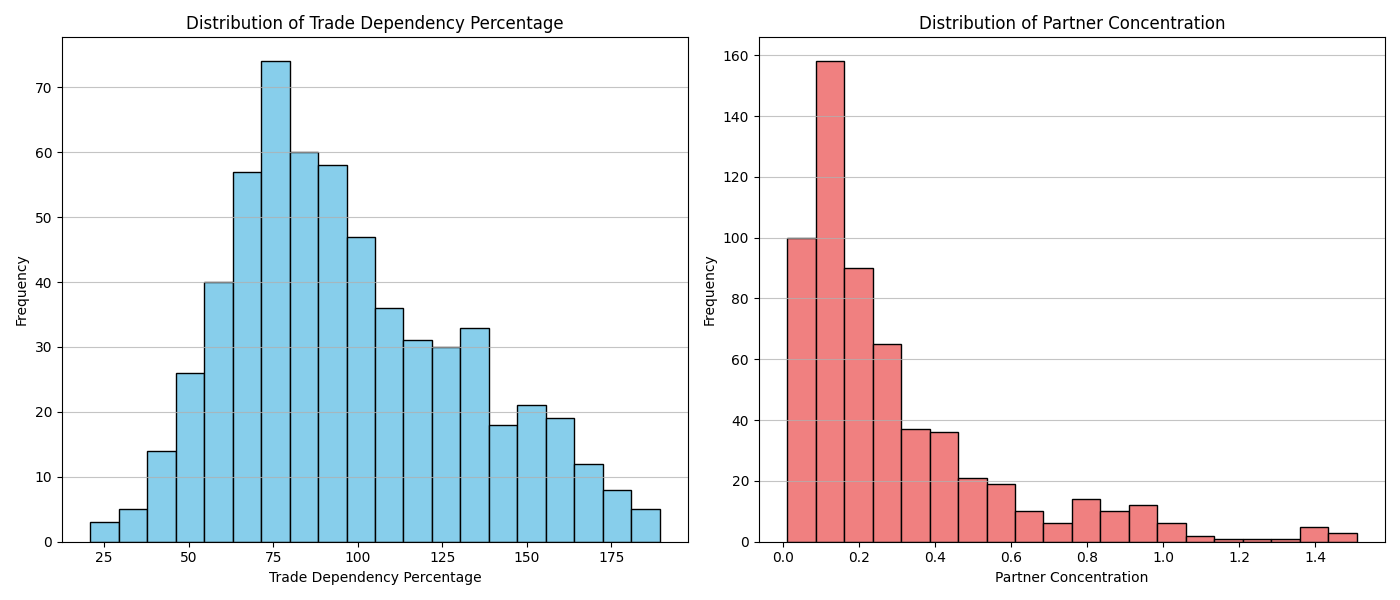

In [32]:
import matplotlib.pyplot as plt
import io
import base64
import IPython.display as display

fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor='w')

# Histogram for Trade_Dependency_Percentage
axes[0].hist(df_pivoted['Trade_Dependency_Percentage'], bins=20, edgecolor='black', color='skyblue')
axes[0].set_title('Distribution of Trade Dependency Percentage', fontsize=12)
axes[0].set_xlabel('Trade Dependency Percentage', fontsize=10)
axes[0].set_ylabel('Frequency', fontsize=10)
axes[0].grid(axis='y', alpha=0.75)

# Histogram for Partner_Concentration
axes[1].hist(df_pivoted['Partner_Concentration'], bins=20, edgecolor='black', color='lightcoral')
axes[1].set_title('Distribution of Partner Concentration', fontsize=12)
axes[1].set_xlabel('Partner Concentration', fontsize=10)
axes[1].set_ylabel('Frequency', fontsize=10)
axes[1].grid(axis='y', alpha=0.75)

plt.tight_layout()

data = io.BytesIO()
plt.savefig(data)
image = F"data:image/png;base64,{base64.b64encode(data.getvalue()).decode()}"
alt = "Histograms of Trade Dependency and Partner Concentration"
display.display(display.Markdown(F"![{alt}]({image})"))
plt.close(fig)